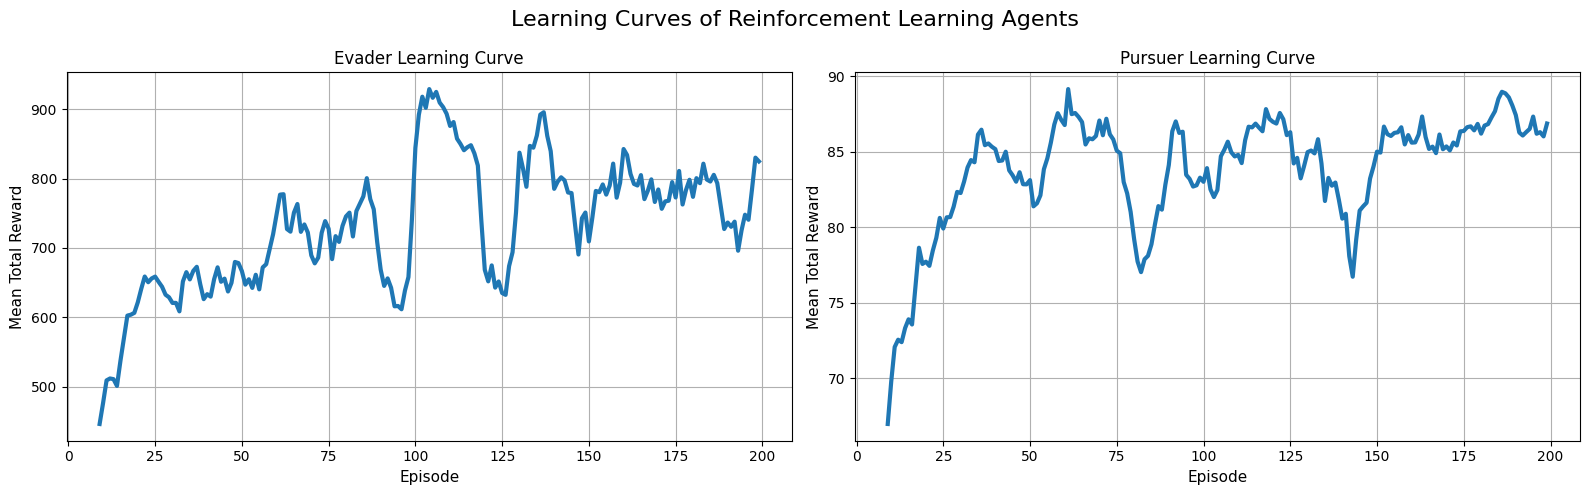

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load pursuer and evader learning data
evaders = pd.read_csv("rl_evaders_results.csv")
pursuers = pd.read_csv("rl_pursuers_results.csv")

# Filter to training phase
evaders_train = evaders[evaders["phase"] == "train"]
pursuers_train = pursuers[pursuers["phase"] == "train"]

# Compute average episode reward
avg_evaders = evaders_train.groupby("episode")["total_reward"].mean()
avg_pursuers = pursuers_train.groupby("episode")["total_reward"].mean()

# Compute rolling averages to smooth curve
evaders_rolling = avg_evaders.rolling(10).mean()
pursuers_rolling = avg_pursuers.rolling(10).mean()

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Plot 1
axes[0].plot(evaders_rolling, linewidth=3)
axes[0].set_xlabel("Episode", fontsize=11)
axes[0].set_ylabel("Mean Total Reward", fontsize=11)
axes[0].set_title("Evader Learning Curve")
axes[0].grid(True)

# Plot 2
axes[1].plot(pursuers_rolling, linewidth=3)
axes[1].set_xlabel("Episode", fontsize=11)
axes[1].set_ylabel("Mean Total Reward", fontsize=11)
axes[1].set_title("Pursuer Learning Curve")
axes[1].grid(True)

fig.suptitle("Learning Curves of Reinforcement Learning Agents", fontsize=16)

plt.tight_layout()
plt.show()